In [2]:
# Importing
import numpy as np
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score,precision_score,f1_score,accuracy_score,classification_report,confusion_matrix

In [3]:
# Load & Clean Data
df = sns.load_dataset("titanic")
df["age"] = df["age"].fillna(df["age"].median(),inplace=True)
df.drop(columns=["deck","embark_town","alive","who","class","adult_male","alone"], inplace=True)
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0], inplace=True)

C:\Users\91706\AppData\Local\Temp\ipykernel_13560\3842067326.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["age"] = df["age"].fillna(df["age"].median(),inplace=True)
C:\Users\91706\AppData\Local\Temp\ipykernel_13560\3842067326.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chain

In [4]:
# encoding for Sex by using sklearn preprocessing module
ct = ColumnTransformer(transformers=[("encoder", OneHotEncoder(),[2])],remainder="passthrough")

result = ct.fit_transform(df)

df = pd.DataFrame(result)

# get feature names from ColumnTransformer
col_names = ct.get_feature_names_out()
print(col_names)

# assign to dataframe
df.columns = col_names


df.columns = [col.split("__")[1] for col in df.columns]
# "encoder__sex_female"  → split by "__" → ["encoder", "sex_female"] → take [1] → "sex_female"
print(df.columns.tolist())

# encoding for Embarked 
df["embarked"] =  df["embarked"].map({"S":1,"C":2,"Q":3})

['encoder__sex_female' 'encoder__sex_male' 'remainder__survived'
 'remainder__pclass' 'remainder__age' 'remainder__sibsp'
 'remainder__parch' 'remainder__fare' 'remainder__embarked']
['sex_female', 'sex_male', 'survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'embarked']


In [5]:
# Train Model
X = df.drop(columns="survived").astype(float)
y = df["survived"].astype(int)


# split the data
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

# feature scaling
sc = StandardScaler()
X_train_scaled = sc.fit_transform (X_train)
X_test_scaled = sc.transform(X_test)

# Model Training
model = LogisticRegression()
model.fit(X_train_scaled,y_train)
y_pred = model.predict(X_test_scaled)


In [6]:
# Evaluate 
print(f"Accuracy : {accuracy_score(y_test,y_pred)*100:.3f}")
print(f"Precision : {precision_score(y_test,y_pred)*100:.3f}")
print(f"Recall : {recall_score(y_test,y_pred)*100:.3f}")
print(f"F1 Score : {f1_score(y_test,y_pred)*100:.3f}")

print("----------------------------------------")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("----------------------------------------")

print("\nFull Report:")
print(classification_report(y_test, y_pred))

Accuracy : 79.888
Precision : 77.143
Recall : 72.973
F1 Score : 75.000
----------------------------------------

Confusion Matrix:
[[89 16]
 [20 54]]
----------------------------------------

Full Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



# Vizualization - FOR SURVIVED VS DIED

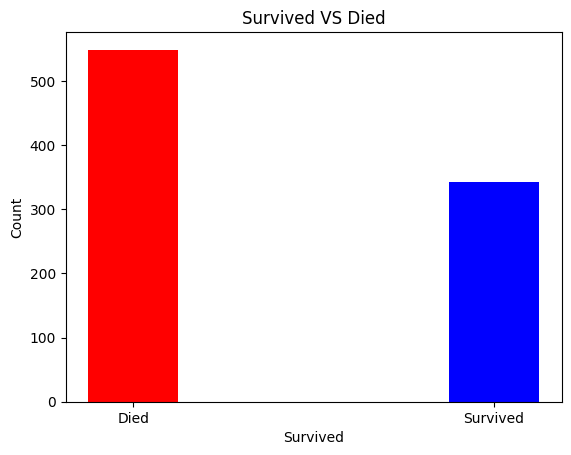

In [7]:

df["survived"].value_counts()
count = df["survived"].value_counts()
x = ["Died","Survived"]
y = [count[0],count[1]]

plt.bar(x,y , color = ["red","blue"], width = 0.25)
plt.xlabel("Survived")
plt.ylabel("Count")
plt.title("Survived VS Died")
plt.show()

Male survived: 109
Male died: 468
Female survived: 233
Female died: 81


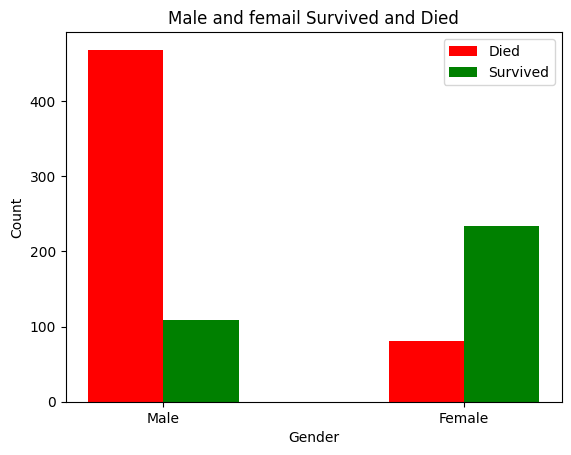

In [8]:
# PLOT 2
# out of males and females  how many survived and died?
male_survived = len(df[(df['sex_male'] == 1) & (df['survived'] == 1)])
male_died = len(df[(df['sex_male'] == 1) & (df['survived'] == 0)])
female_survived = len(df[(df['sex_female'] == 1) & (df['survived'] == 1)])
female_died     = len(df[(df['sex_female'] == 1) & (df['survived'] == 0)])

print(f"Male survived: {male_survived}")
print(f"Male died: {male_died}")
print(f"Female survived: {female_survived}")
print(f"Female died: {female_died}")


# died bars → slightly left of center

x = np.arange(2)   # creates [0, 1] → 2 groups (male, female)
width = 0.25  
plt.bar(x - width/2, [male_died, female_died], width, color='red', label='Died')

# survived bars → slightly right of center
plt.bar(x + width/2, [male_survived, female_survived], width, color='green', label='Survived')
plt.xticks(x, ['Male', 'Female'])   # label x axis groups
plt.xlabel("Gender")
plt.ylabel("Count")
plt.title("Male and femail Survived and Died")
plt.legend()    # shows red=Died, green=Survived
plt.show()

In [9]:
df

,sex_female,sex_male,survived,pclass,age,sibsp,parch,fare,embarked
0,0.0,1.0,0,3,22.0,1,0,7.25,1
1,1.0,0.0,1,1,38.0,1,0,71.2833,2
2,1.0,0.0,1,3,26.0,0,0,7.925,1
3,1.0,0.0,1,1,35.0,1,0,53.1,1
4,0.0,1.0,0,3,35.0,0,0,8.05,1
...,...,...,...,...,...,...,...,...,...
886,0.0,1.0,0,2,27.0,0,0,13.0,1
887,1.0,0.0,1,1,19.0,0,0,30.0,1
888,1.0,0.0,0,3,28.0,1,2,23.45,1
889,0.0,1.0,1,1,26.0,0,0,30.0,2
